## Understanding LSTM Fundamentals

### What is LSTM?

An LSTM (Long Short-Term Memory) is an advanced type of recurrent neural network (RNN) designed to overcome the vanishing gradient problem and capture long-term dependencies in sequential data.

Key Characteristics:

- Sequential Processing: Processes input data step by step, like an RNN.

- Memory Cells: Uses special units (cells) with gates to store and update information over long sequences.

- Gates: Includes input, forget, and output gates that control the flow of information.

- Long-Term Dependency Handling: Can remember relevant information across hundreds of time steps.

Suitable for:
Long sequences such as natural language, time series forecasting, and speech recognition.



### LSTM Architecture


In [68]:
# Basic LSTM structure
# Input: [batch_size, sequence_length, features]
# Hidden State: [batch_size, hidden_units]
# Output: [batch_size, output_units]

## Code Implementation

### Change Working directory

In [69]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
import os
os.chdir('/content/drive/MyDrive/DAM202-Practicals')
os.listdir()

['clinical.txt',
 'Word2Vec.ipynb',
 'alice.txt',
 '.ipynb_checkpoints',
 'word2vec_model(CBOW).model',
 'word2vec_model(SG).model',
 'weather_data.csv',
 'Practical2(Word2Vec).ipynb',
 'fasttext_model.model',
 'CBOW-fasttext_model.model.wv.vectors_ngrams.npy',
 'CBOW-fasttext_model.model',
 'Assignment1.ipynb',
 'Practical3.ipynb',
 'best_simple_rnn_model.h5',
 'best_LSTM_model.h5',
 'Practical4-GRU.ipynb',
 'Practical4-LSTM.ipynb',
 'lstm_tuning']

### 1.1 Installation and Imports

In [71]:
#Install required packages (run in terminal)
!pip install tensorflow pandas numpy matplotlib scikit-learn seaborn keras-tuner

In [72]:
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.layers import Input

# KerasTuner for hyperparameter optimization
import keras_tuner as kt

# Data preprocessing tools
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set random seeds for reproducible results
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("KerasTuner installed successfully!")
print("Setup completed successfully!")

TensorFlow version: 2.19.0
KerasTuner installed successfully!
Setup completed successfully!


### 1.2 Data Loading and Exploration

#### 1.2.1  Load Bangladesh Weather Data

In [73]:
def load_weather_data(file_path):
    """
    Load Bangladesh weather data and create proper structure

    Expected CSV format:
    Year, Day, Wind_Speed, Specific_Humidity, Relative_Humidity, Precipitation, Temperature
    Example: 1990, 240, 3.26, 15.62, 65, 0.69, 30.65
    """

    # Load the CSV file
    df = pd.read_csv('/content/drive/MyDrive/DAM202-Practicals/weather_data.csv') #Same working directory

    # Define column names based on your data description
    column_names = [
        'Year', 'Day', 'Wind_Speed', 'Specific_Humidity',
        'Relative_Humidity', 'Precipitation', 'Temperature'
    ]

    # Assign column names if they're not already set
    if len(df.columns) == len(column_names):
        df.columns = column_names

    # Create proper date from Year and Day
    df['Date'] = pd.to_datetime(df['Year'] * 1000 + df['Day'], format='%Y%j')

    # Set date as index for time series analysis
    df.set_index('Date', inplace=True)

    # Remove original Year and Day columns
    df.drop(['Year', 'Day'], axis=1, inplace=True)

    print(f"Data loaded successfully!")
    print(f"Shape: {df.shape}")
    print(f"Date range: {df.index.min()} to {df.index.max()}")

    return df

# Load your data
data_file = "bangladesh_weather_data.csv"  # Replace with your file path
df = load_weather_data(data_file)


Data loaded successfully!
Shape: (12113, 5)
Date range: 1990-01-01 00:00:00 to 2023-03-01 00:00:00


In [74]:
df.head()

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature
Date,,,,,
1990-01-01,1.08,5.68,53.06,0.0,16.33
1990-01-02,1.13,5.92,58.06,0.0,15.68
1990-01-03,1.33,5.68,52.69,0.0,16.56
1990-01-04,1.09,5.19,47.19,0.0,17.09
1990-01-05,0.94,4.82,42.88,0.0,17.26


In [75]:
#Compare with original dataset
main_df = pd.read_csv('weather_data.csv') #Same working directory
main_df.head()

,Year,Day,Wind Speed,Specific Humidity,Relative Humidity,Precipitation,Temperature
0,1990,1,1.08,5.68,53.06,0.0,16.33
1,1990,2,1.13,5.92,58.06,0.0,15.68
2,1990,3,1.33,5.68,52.69,0.0,16.56
3,1990,4,1.09,5.19,47.19,0.0,17.09
4,1990,5,0.94,4.82,42.88,0.0,17.26


#### 1.2.2 Data Exploration and Visualization

=== BANGLADESH WEATHER DATA EXPLORATION ===
Dataset Shape: (12113, 5)
Date Range: 1990-01-01 to 2023-03-01
Total Days: 12113 days
Years Covered: 34 years

=== BASIC STATISTICS ===
       Wind_Speed  Specific_Humidity  Relative_Humidity  Precipitation  \
count    12113.00           12113.00           12113.00       12113.00   
mean         1.31              15.21              74.64           7.18   
std          0.54               5.53              15.29          13.13   
min          0.44               2.62              15.81           0.00   
25%          0.95               9.95              65.25           0.00   
50%          1.15              16.17              79.62           1.16   
75%          1.52              20.57              86.56           9.26   
max          5.34              24.29              96.12         170.63   

       Temperature  
count     12113.00  
mean         25.04  
std           4.37  
min          11.19  
25%          21.43  
50%          26.93  
75%   

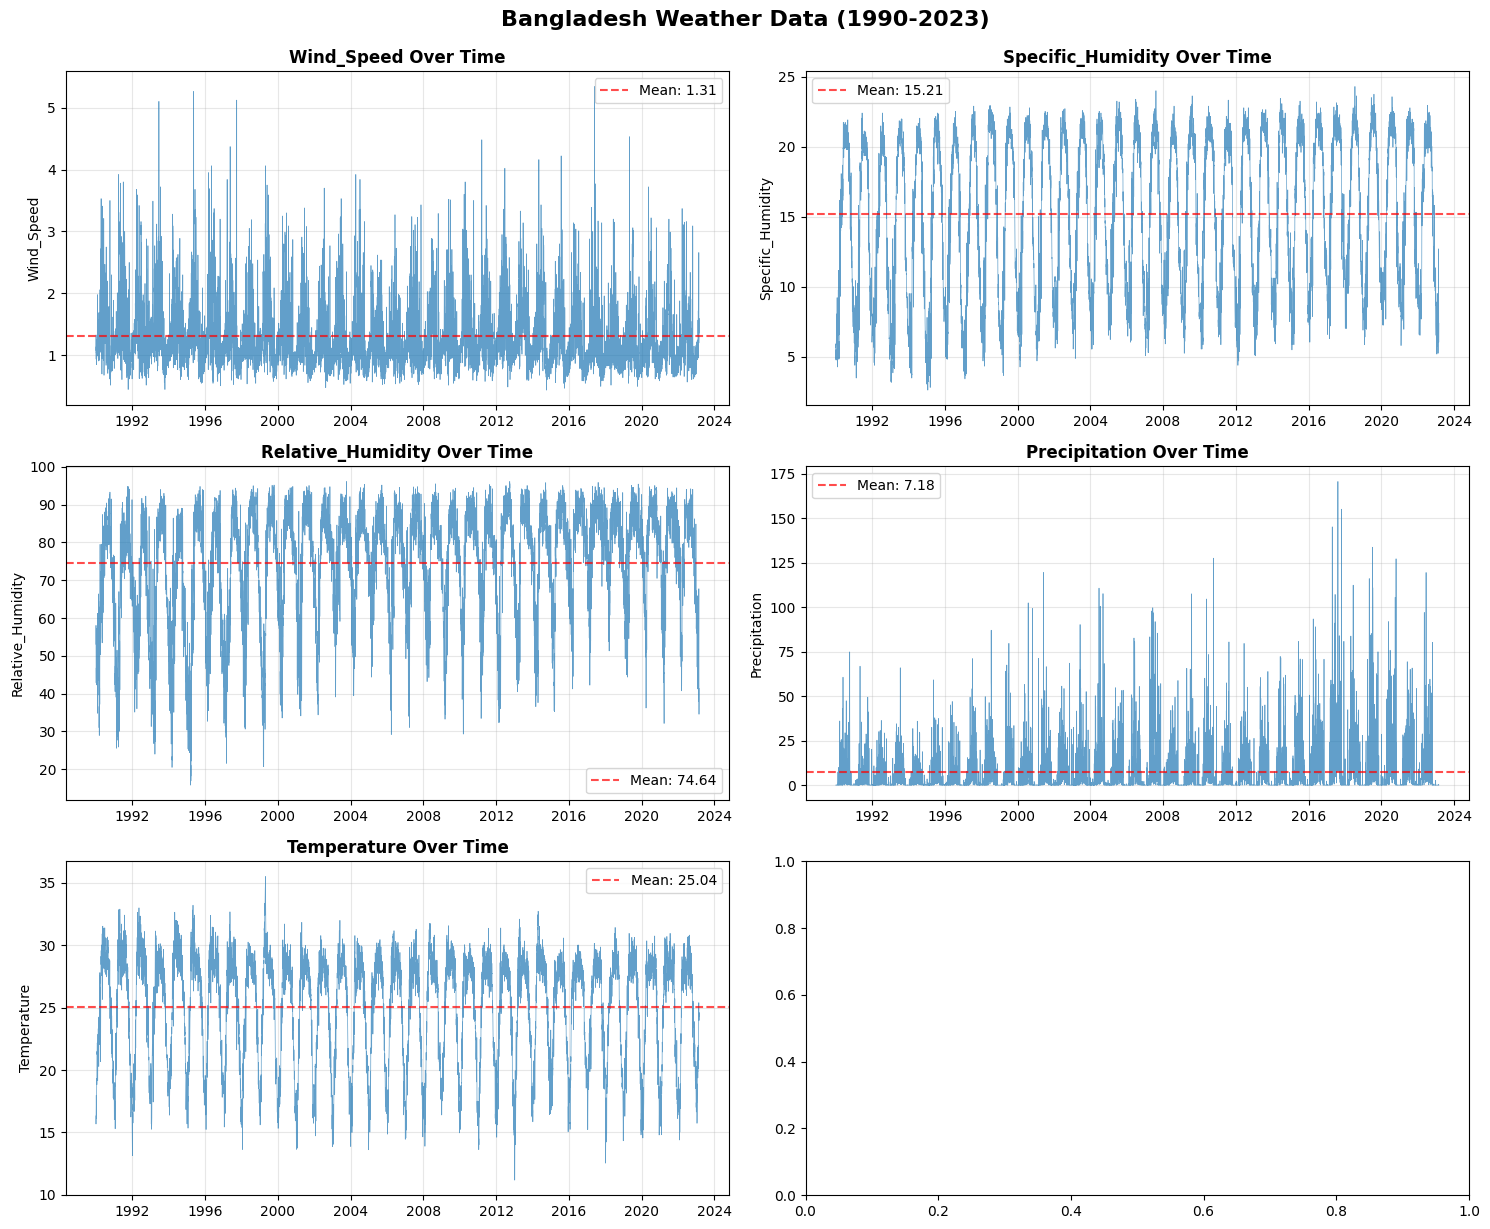

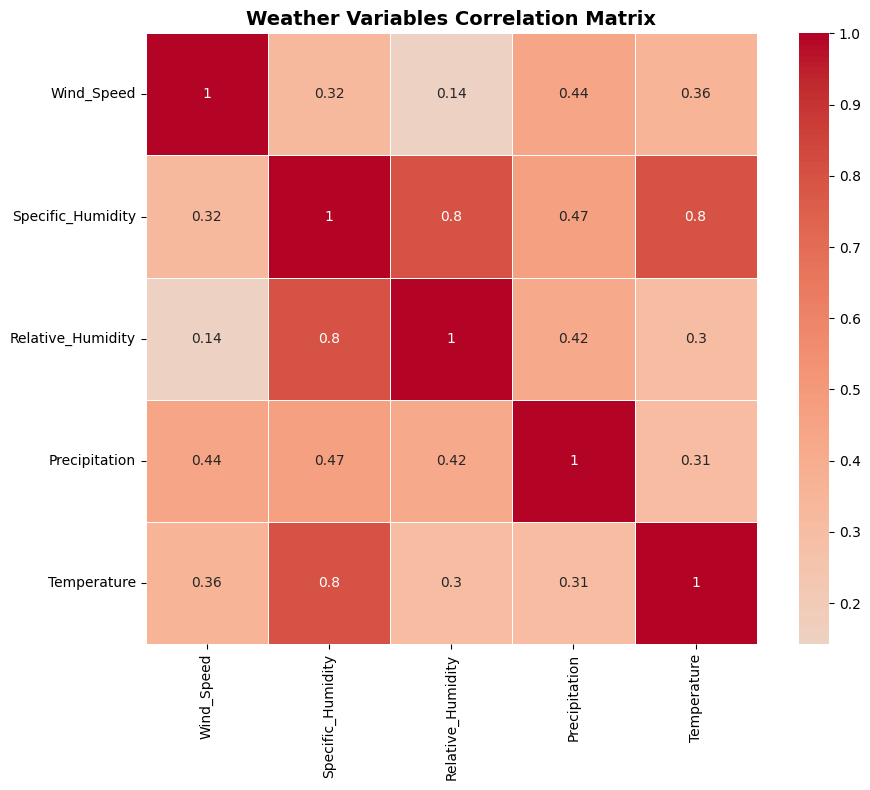

In [76]:
def explore_weather_data(df):
    """
    Comprehensive exploration of weather data
    """

    print("=== BANGLADESH WEATHER DATA EXPLORATION ===")
    print(f"Dataset Shape: {df.shape}")
    print(f"Date Range: {df.index.min().strftime('%Y-%m-%d')} to {df.index.max().strftime('%Y-%m-%d')}")
    print(f"Total Days: {len(df)} days")
    print(f"Years Covered: {df.index.year.nunique()} years")

    # Basic statistics
    print("\n=== BASIC STATISTICS ===")
    print(df.describe().round(2))

    # Check for missing values
    print("\n=== MISSING VALUES ===")
    missing_values = df.isnull().sum()
    print(missing_values)

    # Data types
    print("\n=== DATA TYPES ===")
    print(df.dtypes)

    # Visualize all weather variables
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, column in enumerate(df.columns):
        axes[i].plot(df.index, df[column], alpha=0.7, linewidth=0.5)
        axes[i].set_title(f'{column} Over Time', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(column)
        axes[i].grid(True, alpha=0.3)

        # Add some statistics to the plot
        mean_val = df[column].mean()
        axes[i].axhline(y=mean_val, color='red', linestyle='--', alpha=0.7,
                       label=f'Mean: {mean_val:.2f}')
        axes[i].legend()

    plt.tight_layout()
    plt.suptitle('Bangladesh Weather Data (1990-2023)', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    # Correlation matrix
    plt.figure(figsize=(10, 8))
    correlation_matrix = df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
                square=True, linewidths=0.5)
    plt.title('Weather Variables Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return df

# Explore the data
df_explored = explore_weather_data(df)


### 1.3 Data Preprocessing for LSTM

#### 1.3.1 Data Cleaning

In [77]:
def clean_weather_data(df):
    """
    Clean the weather data for LSTM processing
    """

    print("=== DATA CLEANING PROCESS ===")

    # Make a copy to avoid modifying original data
    df_clean = df.copy()

    # 1. Handle missing values
    print(f"Missing values before cleaning: {df_clean.isnull().sum().sum()}")

    # Forward fill then backward fill for time series data
    df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')

    print(f"Missing values after cleaning: {df_clean.isnull().sum().sum()}")

    # 2. Remove outliers using IQR method
    print("\n=== OUTLIER REMOVAL ===")

    for column in df_clean.columns:
        Q1 = df_clean[column].quantile(0.25)
        Q3 = df_clean[column].quantile(0.75)
        IQR = Q3 - Q1

        # Define outlier bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Count outliers
        outliers_before = ((df_clean[column] < lower_bound) |
                          (df_clean[column] > upper_bound)).sum()

        # Remove outliers by clipping
        df_clean[column] = df_clean[column].clip(lower=lower_bound, upper=upper_bound)

        print(f"{column}: {outliers_before} outliers handled")

    # 3. Basic feature engineering for time series
    df_clean['Month'] = df_clean.index.month
    df_clean['Day_of_Year'] = df_clean.index.dayofyear

    # Add simple moving averages (helpful for Simple RNN)
    df_clean['Temp_MA_3'] = df_clean['Temperature'].rolling(window=3).mean()
    df_clean['Temp_MA_7'] = df_clean['Temperature'].rolling(window=7).mean()

    # Remove rows with NaN values created by moving averages
    df_clean.dropna(inplace=True)

    print(f"\nFinal dataset shape: {df_clean.shape}")

    return df_clean

# Clean the data
df_clean = clean_weather_data(df_explored)

=== DATA CLEANING PROCESS ===
Missing values before cleaning: 0
Missing values after cleaning: 0

=== OUTLIER REMOVAL ===
Wind_Speed: 661 outliers handled
Specific_Humidity: 0 outliers handled
Relative_Humidity: 152 outliers handled
Precipitation: 1089 outliers handled
Temperature: 0 outliers handled

Final dataset shape: (12107, 9)


/tmp/ipython-input-3097781953.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean = df_clean.fillna(method='ffill').fillna(method='bfill')


In [78]:
df_clean.head()

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-07,1.04,5.49,46.81,0.0,17.98,1,7,17.510000,16.884286
1990-01-08,1.06,5.07,44.25,0.0,17.58,1,8,17.616667,17.062857
1990-01-09,0.85,4.82,42.31,0.0,17.25,1,9,17.603333,17.287143
1990-01-10,1.14,4.76,45.38,0.0,16.33,1,10,17.053333,17.254286
1990-01-11,1.07,5.07,48.44,0.0,16.15,1,11,16.576667,17.120000


#### 1.3.2 Data Normalization for LSTM

In [79]:
def normalize_data_for_LSTM(df, target_column='Temperature'):
    """
    Normalize data for LSTM training

    Important: We fit the scaler only on training data to prevent data leakage
    """

    print(f"=== DATA NORMALIZATION FOR LSTM ===")
    print(f"Target variable: {target_column}")

    # Separate features and target
    feature_columns = [col for col in df.columns if col != target_column]

    print(f"Feature columns: {feature_columns}")
    print(f"Number of features: {len(feature_columns)}")

    # Initialize scalers
    feature_scaler = MinMaxScaler(feature_range=(0, 1))
    target_scaler = MinMaxScaler(feature_range=(0, 1))

    return df, feature_columns, feature_scaler, target_scaler

# Prepare for normalization
df_processed, feature_columns, feature_scaler, target_scaler = normalize_data_for_LSTM(df_clean)

=== DATA NORMALIZATION FOR LSTM ===
Target variable: Temperature
Feature columns: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Number of features: 8


In [80]:
df_processed.head(2)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-07,1.04,5.49,46.81,0.0,17.98,1,7,17.510000,16.884286
1990-01-08,1.06,5.07,44.25,0.0,17.58,1,8,17.616667,17.062857


These lines are for basic feature engineering in time series analysis, which helps a neural network learn patterns better by adding informative features derived from the raw data.

What are these features?
- Month: The month from each date (e.g., January, February, etc.), which helps encode potential seasonal effects (like monsoons or cold seasons).

- Day_of_Year: The position of each date in the year (e.g., 1 for January 1st, 365 for December 31st), which can capture cyclic trends and annual seasonality.

- Temp_MA_3: The average temperature over the past 3 days for each day.

- Temp_MA_7: The average temperature over the past 7 days for each day.

Why are they done?
- Month and Day_of_Year transform raw date information into numerical features so that machine learning models can learn from seasonal patterns (e.g., temperature might be higher in June than in December).

- Moving averages (Temp_MA_3 and Temp_MA_7) smooth the original temperature signal. They reduce noise and short-term fluctuations, making longer-term trends and cycles more visible for the model. These features help the neural network understand not just today's temperature but also recent context, which is important for forecasting.

Why do we do this for time series models?
- Expose Patterns: Weather data shows seasonal/cyclic behaviors; encoding month and day-of-year helps the model pick up on regular patterns.

- Reduce Noise: Moving averages help to “smooth out” outlier values, giving the model a clearer picture of underlying trends.

Learning Context: RNNs thrive when they can access recent history. Including moving averages lets the model access summarized context of the recent past, not just raw daily values

#### 1.3.3 Time Series Train-Test Split

In [81]:
def create_time_series_split(df, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15):
    """
    Create time-aware train/validation/test split for time series

    Important: No shuffling to maintain temporal order!
    """

    print(f"=== TIME SERIES DATA SPLITTING ===")

    n_samples = len(df)

    # Calculate split indices
    train_end = int(n_samples * train_ratio)
    val_end = int(n_samples * (train_ratio + val_ratio))

    # Split data maintaining temporal order
    train_data = df.iloc[:train_end].copy()
    val_data = df.iloc[train_end:val_end].copy()
    test_data = df.iloc[val_end:].copy()

    print(f"Training data: {len(train_data)} samples ({train_data.index.min()} to {train_data.index.max()})")
    print(f"Validation data: {len(val_data)} samples ({val_data.index.min()} to {val_data.index.max()})")
    print(f"Test data: {len(test_data)} samples ({test_data.index.min()} to {test_data.index.max()})")

    return train_data, val_data, test_data

# Split the data
train_data, val_data, test_data = create_time_series_split(df_processed)

=== TIME SERIES DATA SPLITTING ===
Training data: 8474 samples (1990-01-07 00:00:00 to 2013-03-20 00:00:00)
Validation data: 1816 samples (2013-03-21 00:00:00 to 2018-03-10 00:00:00)
Test data: 1817 samples (2018-03-11 00:00:00 to 2023-03-01 00:00:00)


In [82]:
train_data.head(2)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
1990-01-07,1.04,5.49,46.81,0.0,17.98,1,7,17.510000,16.884286
1990-01-08,1.06,5.07,44.25,0.0,17.58,1,8,17.616667,17.062857


### 1.4 Creating Sequences for LSTM

#### Understanding Sequence Creation
LSTMs are designed to handle longer sequences compared to simple RNNs. Instead of being limited to very short inputs, LSTMs can capture patterns across tens or even hundreds of time steps thanks to their gating mechanism. However, using extremely long sequences can make training slower and more complex, so it’s best to choose a sequence length that balances both short-term fluctuations and long-term patterns in the data.



In [83]:
def create_sequences_for_LSTM(features, target, sequence_length=30):
    """
    Create sequences for LSTM  training

    For LSTM, we use longer sequences for better performance

    Parameters:
    - data: scaled data array
    - target_column: index of target column
    - sequence_length: number of time steps to look back (keep it short for Simple RNN)
    """

    sequences = []
    targets = []

    # Create sequences
    for i in range(sequence_length, len(features)):
        # Get sequence of past 'sequence_length' days
        sequences.append(features[i-sequence_length:i])  # Shape: (sequence_length, features)

        # Get target (next day's temperature)
        targets.append(target[i])  # Single value

    return np.array(sequences), np.array(targets)

In [84]:
def prepare_data_for_LSTM(train_data, val_data, test_data,
                               feature_columns, target_column,
                               feature_scaler, target_scaler,
                               sequence_length=60):
    """
    Complete data preparation pipeline for LSTM
    """

    print(f"=== PREPARING DATA FOR LSTM ===")
    print(f"Sequence length: {sequence_length} days")
    print(f"Target: {target_column}")
    print(f"Features: {feature_columns}")

    # 1. Scale the data (fit only on training data!)
    train_features_scaled = feature_scaler.fit_transform(train_data[feature_columns])
    train_target_scaled = target_scaler.fit_transform(train_data[[target_column]])
    print(f"Train Target : {train_target_scaled.flatten().shape}")

    val_features_scaled = feature_scaler.transform(val_data[feature_columns])
    val_target_scaled = target_scaler.transform(val_data[[target_column]])

    test_features_scaled = feature_scaler.transform(test_data[feature_columns])
    test_target_scaled = target_scaler.transform(test_data[[target_column]])

    # 2. Combine features and target for sequence creation
    train_combined = np.column_stack([train_features_scaled, train_target_scaled])
    val_combined = np.column_stack([val_features_scaled, val_target_scaled])
    test_combined = np.column_stack([test_features_scaled, test_target_scaled])

    # 3. Find target column index in combined array
    #target_idx = train_data.columns.get_loc('Temperature')

    # 4. Create sequences
    X_train, y_train = create_sequences_for_LSTM(train_features_scaled, train_target_scaled.flatten(), sequence_length)
    X_val, y_val = create_sequences_for_LSTM(val_features_scaled, val_target_scaled.flatten(), sequence_length)
    X_test, y_test = create_sequences_for_LSTM(test_features_scaled, test_target_scaled.flatten(), sequence_length)


    print(f"Training sequences: {X_train.shape}")
    print(f"Training targets: {y_train.shape}")
    print(f"Validation sequences: {X_val.shape}")
    print(f"Test sequences: {X_test.shape}")

    return (X_train, y_train), (X_val, y_val), (X_test, y_test)

# Prepare sequences (using long sequence length for LSTM)
SEQUENCE_LENGTH = 60  # Only 30 days - optimal for LSTM

(X_train, y_train), (X_val, y_val), (X_test, y_test) = prepare_data_for_LSTM(
    train_data, val_data, test_data,
    feature_columns, 'Temperature',
    feature_scaler, target_scaler,
    sequence_length=SEQUENCE_LENGTH
)

print("Data preparation completed successfully!")

=== PREPARING DATA FOR LSTM ===
Sequence length: 60 days
Target: Temperature
Features: ['Wind_Speed', 'Specific_Humidity', 'Relative_Humidity', 'Precipitation', 'Month', 'Day_of_Year', 'Temp_MA_3', 'Temp_MA_7']
Train Target : (8474,)
Training sequences: (8414, 60, 8)
Training targets: (8414,)
Validation sequences: (1756, 60, 8)
Test sequences: (1757, 60, 8)
Data preparation completed successfully!


In [87]:
X_train[100]

array([[5.35064935e-01, 5.97098737e-01, 4.83886369e-01, 4.40604752e-02,
        2.72727273e-01, 2.90410959e-01, 7.44755737e-01, 7.23740253e-01],
       [1.00000000e+00, 6.08329434e-01, 5.04734622e-01, 1.58099352e-01,
        2.72727273e-01, 2.93150685e-01, 7.42925524e-01, 7.31800013e-01],
       [1.00000000e+00, 5.97098737e-01, 4.99801066e-01, 2.19006479e-01,
        2.72727273e-01, 2.95890411e-01, 7.33633676e-01, 7.32258699e-01],
       [1.00000000e+00, 6.88348152e-01, 6.54014482e-01, 8.13822894e-01,
        2.72727273e-01, 2.98630137e-01, 7.19132761e-01, 7.25640522e-01],
       [1.00000000e+00, 7.22976135e-01, 7.36452614e-01, 1.00000000e+00,
        2.72727273e-01, 3.01369863e-01, 6.98155709e-01, 7.19939716e-01],
       [8.88311688e-01, 7.20168460e-01, 6.78841410e-01, 4.15118790e-01,
        2.72727273e-01, 3.04109589e-01, 6.92524286e-01, 7.15418387e-01],
       [8.05194805e-01, 6.94431446e-01, 5.94175221e-01, 6.00431965e-02,
        2.72727273e-01, 3.06849315e-01, 7.10404055e-01, 7.

### 1.5 Building LSTM Model

#### 1.5.1 Understanding LSTM Architecture

In [90]:
def build_model(hp):
    """
    Build LSTM model for KerasTuner hyperparameter optimization

    This function defines the search space for hyperparameters:
    - LSTM units: 32, 64, 128, 256
    - Dropout rates: 0.1 to 0.5
    - Learning rate: 0.0001 to 0.01
    - Number of LSTM layers: 1 or 2
    """

    model = Sequential(name="Tuned_LSTM_Weather_Predictor")

    # Input layer
    model.add(Input(shape=(X_train.shape[1], X_train.shape[2]), name='Input_Layer'))

    # First LSTM layer with tunable parameters
    units_1 = hp.Choice('units_1', values=[32, 64, 128, 256])
    dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.5, step=0.1)

    model.add(LSTM(
        units=units_1,
        activation='tanh',
        dropout=dropout_1,
        recurrent_dropout=dropout_1,
        return_sequences=hp.Boolean('return_sequences'),  # Whether to add second LSTM
        name='LSTM_Layer_1'
    ))

    # Optional second LSTM layer
    if hp.Boolean('return_sequences'):
        units_2 = hp.Choice('units_2', values=[16, 32, 64, 128])
        dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.4, step=0.1)

        model.add(LSTM(
            units=units_2,
            activation='tanh',
            dropout=dropout_2,
            recurrent_dropout=dropout_2,
            name='LSTM_Layer_2'
        ))

    # Additional dropout layer
    model.add(Dropout(hp.Float('final_dropout', 0.1, 0.5, step=0.1), name='Final_Dropout'))

    # Output layer
    model.add(Dense(units=1, activation='linear', name='Output_Layer'))

    # Compile with tunable learning rate
    learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mean_squared_error',
        metrics=['mean_absolute_error', 'mean_absolute_percentage_error']
    )

    return model

# Display the hyperparameter search space
print("=== HYPERPARAMETER SEARCH SPACE ===")
print(" LSTM Units (Layer 1): [32, 64, 128, 256]")
print(" LSTM Units (Layer 2): [16, 32, 64, 128] (if enabled)")
print(" Dropout Rates: 0.1 to 0.5 (step: 0.1)")
print(" Learning Rate: 0.0001 to 0.01 (log scale)")
print(" Architecture: Single or Double LSTM layers")
print(" Total combinations: ~1000+ possible models")
print("\nModel builder function ready for hyperparameter tuning!")

=== HYPERPARAMETER SEARCH SPACE ===
 LSTM Units (Layer 1): [32, 64, 128, 256]
 LSTM Units (Layer 2): [16, 32, 64, 128] (if enabled)
 Dropout Rates: 0.1 to 0.5 (step: 0.1)
 Learning Rate: 0.0001 to 0.01 (log scale)
 Architecture: Single or Double LSTM layers
 Total combinations: ~1000+ possible models

Model builder function ready for hyperparameter tuning!


#### 1.5.2 KerasTuner Hyperparameter Optimization

In [92]:
def setup_keras_tuner(max_trials=20, executions_per_trial=1):
    """
    Setup KerasTuner RandomSearch for LSTM hyperparameter optimization

    Parameters:
    - max_trials: Maximum number of different hyperparameter combinations to try
    - executions_per_trial: Number of times to train each combination (for averaging)
    """

    print(f"=== SETTING UP KERAS TUNER ===")
    print(f" Search Strategy: RandomSearch")
    print(f" Max Trials: {max_trials}")
    print(f" Executions per Trial: {executions_per_trial}")
    print(f" Objective: Minimize validation loss")

    # Initialize RandomSearch tuner
    tuner = kt.RandomSearch(
        hypermodel=build_model,
        objective='val_loss',  # Minimize validation loss
        max_trials=max_trials,
        executions_per_trial=executions_per_trial,
        directory='lstm_tuning',
        project_name='weather_prediction_lstm',
        overwrite=True,  # Overwrite previous tuning sessions
        seed=42  # For reproducible results
    )

    return tuner

# Setup the tuner
tuner = setup_keras_tuner(max_trials=15, executions_per_trial=1)

# Display search space summary
tuner.search_space_summary()

=== SETTING UP KERAS TUNER ===
 Search Strategy: RandomSearch
 Max Trials: 15
 Executions per Trial: 1
 Objective: Minimize validation loss
Search space summary
Default search space size: 5
units_1 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
dropout_1 (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
return_sequences (Boolean)
{'default': False, 'conditions': []}
final_dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [94]:
def run_hyperparameter_search(tuner, X_train, y_train, X_val, y_val,
                              epochs=50, batch_size=32):
    """
    Execute the hyperparameter search process
    """

    print("=== STARTING HYPERPARAMETER SEARCH ===")
    print("🚀 This process will take some time...")
    # Get max_trials from the tuner's oracle
    max_trials = getattr(tuner.oracle, 'max_trials', 15)  # Default to 15 if not found
    print(f"⏱️ Expected time: ~{max_trials * epochs // 10} minutes (approx)")
    print("📈 Progress will be shown below:")
    print("-" * 60)

    # Define callbacks for each trial
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=0,
            min_delta=0.001
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=0
        )
    ]

    # Start the search
    tuner.search(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
        shuffle=False  # Important for time series
    )

    print("\n" + "=" * 60)
    print("🎉 HYPERPARAMETER SEARCH COMPLETED!")
    print("=" * 60)

    return tuner

# Run the hyperparameter search
print("Starting hyperparameter optimization...")
print("Note: This will try 15 different combinations of hyperparameters")
print("Each trial will train for up to 50 epochs with early stopping")

tuner = run_hyperparameter_search(
    tuner, X_train, y_train, X_val, y_val,
    epochs=50, batch_size=32
)

Trial 15 Complete [00h 13m 06s]
val_loss: 0.0035548494197428226

Best val_loss So Far: 0.0015656896866858006
Total elapsed time: 03h 02m 01s

🎉 HYPERPARAMETER SEARCH COMPLETED!


#### 1.5.3 Analyzing Tuning Results

=== HYPERPARAMETER TUNING RESULTS ANALYSIS ===

🏆 TOP PERFORMING MODELS:
🥇 BEST HYPERPARAMETERS:
------------------------------
   units_1: 128
   dropout_1: 0.1
   return_sequences: True
   final_dropout: 0.1
   learning_rate: 0.008347597753558379
   units_2: 128
   dropout_2: 0.30000000000000004

📊 TOP 5 MODELS PERFORMANCE:
--------------------------------------------------
   Rank 1: Validation Loss = 0.001566
        Units: 128, Dropout: 0.10, LR: 8.35e-03, Two-Layer: True
   Rank 2: Validation Loss = 0.001711
        Units: 128, Dropout: 0.10, LR: 5.98e-03, Two-Layer: False
   Rank 3: Validation Loss = 0.001779
        Units: 64, Dropout: 0.10, LR: 9.08e-03, Two-Layer: True
   Rank 4: Validation Loss = 0.002841
        Units: 64, Dropout: 0.10, LR: 7.97e-04, Two-Layer: False
   Rank 5: Validation Loss = 0.002973
        Units: 32, Dropout: 0.30, LR: 9.75e-04, Two-Layer: False


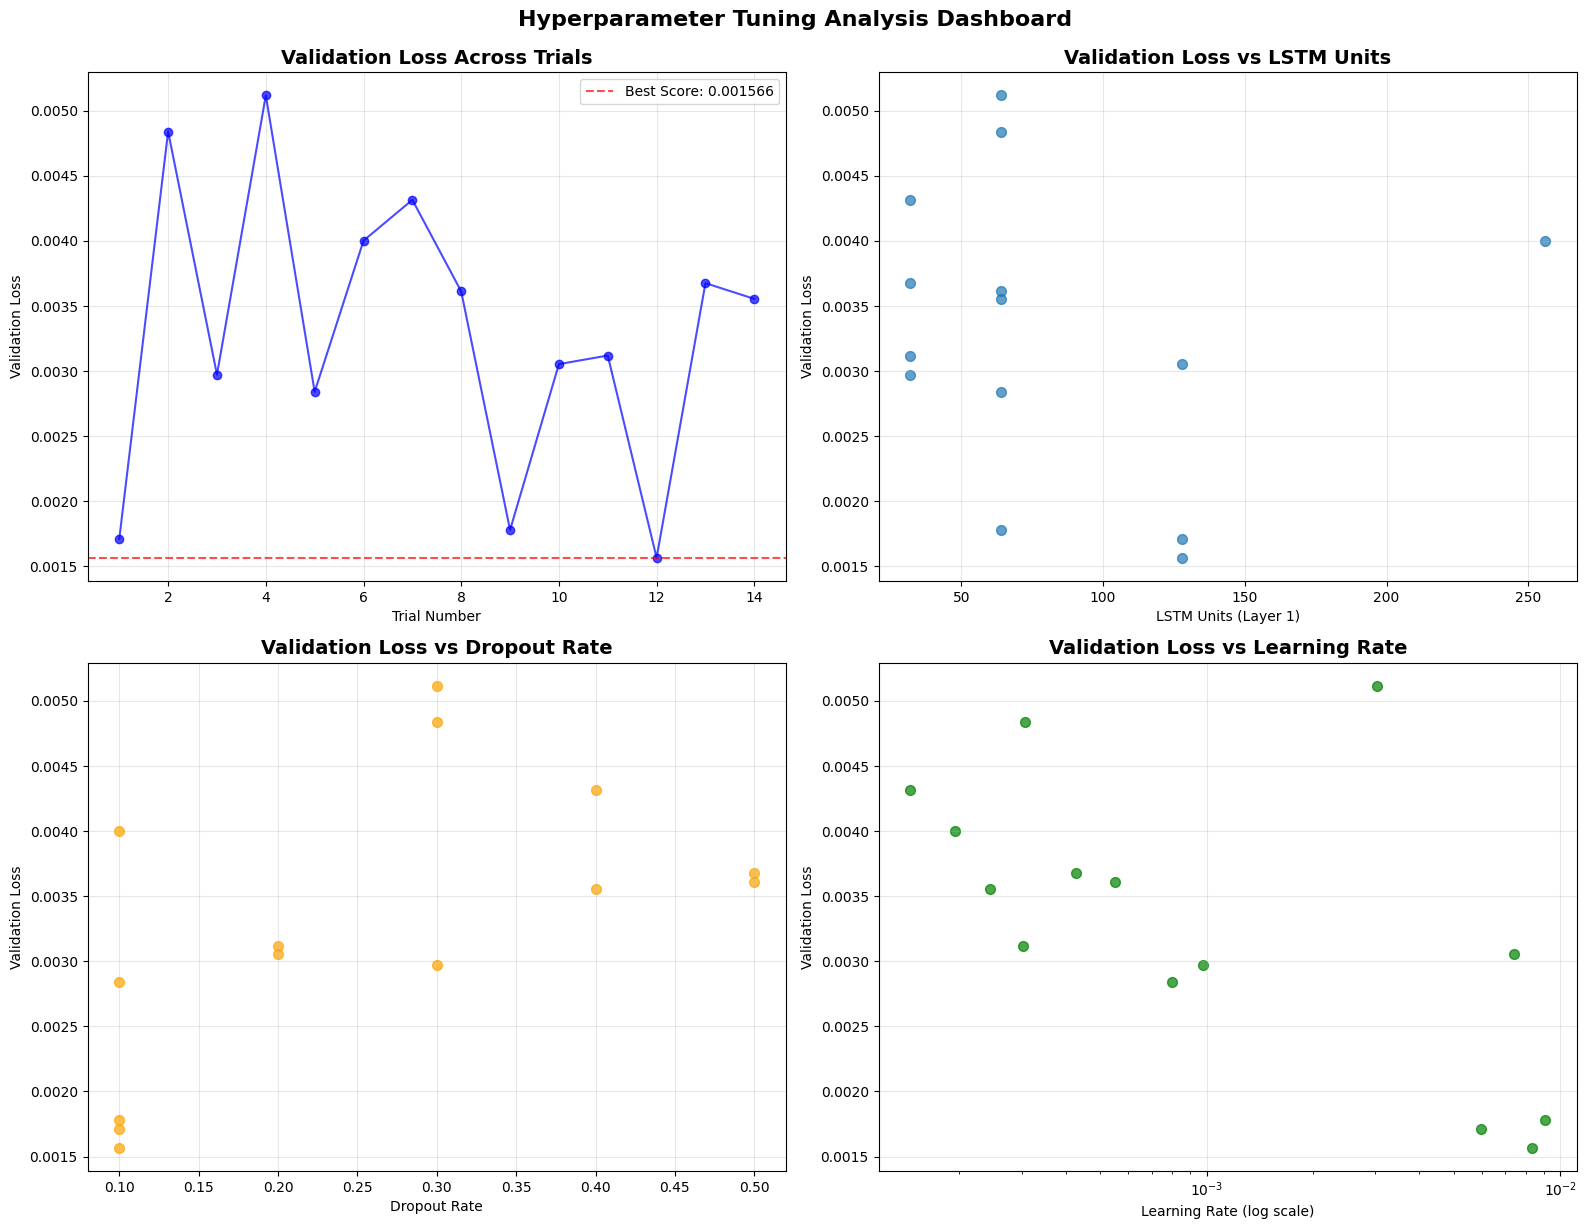

In [98]:
def analyze_tuning_results(tuner, top_n=5):
    """
    Comprehensive analysis of hyperparameter tuning results
    """

    print("=== HYPERPARAMETER TUNING RESULTS ANALYSIS ===")
    print("\n🏆 TOP PERFORMING MODELS:")
    print("=" * 70)

    # Get best hyperparameters
    best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

    # Display best hyperparameters
    print("🥇 BEST HYPERPARAMETERS:")
    print("-" * 30)
    for param, value in best_hps.values.items():
        print(f"   {param}: {value}")

    # Get top models and their scores
    print(f"\n📊 TOP {top_n} MODELS PERFORMANCE:")
    print("-" * 50)

    best_trials = tuner.oracle.get_best_trials(num_trials=top_n)
    for i, trial in enumerate(best_trials, 1):
        score = trial.score
        print(f"   Rank {i}: Validation Loss = {score:.6f}")

        # Show key hyperparameters for each top model
        trial_hps = trial.hyperparameters
        units_1 = trial_hps.values.get('units_1', 'N/A')
        dropout_1 = trial_hps.values.get('dropout_1', 'N/A')
        lr = trial_hps.values.get('learning_rate', 'N/A')
        return_seq = trial_hps.values.get('return_sequences', False)

        print(f"        Units: {units_1}, Dropout: {dropout_1:.2f}, LR: {lr:.2e}, Two-Layer: {return_seq}")

    # Create visualization of results
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Trial scores over time
    trial_scores = [trial.score for trial in tuner.oracle.trials.values() if trial.score is not None]
    if trial_scores: # Check if trial_scores is not empty after filtering
        axes[0, 0].plot(range(1, len(trial_scores) + 1), trial_scores, 'bo-', alpha=0.7)
        axes[0, 0].axhline(y=min(trial_scores), color='r', linestyle='--', alpha=0.7,
                          label=f'Best Score: {min(trial_scores):.6f}')
        axes[0, 0].set_title('Validation Loss Across Trials', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Trial Number')
        axes[0, 0].set_ylabel('Validation Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
    else:
        axes[0, 0].set_title('Validation Loss Across Trials (No valid scores)', fontsize=14, fontweight='bold')


    # 2. Hyperparameter distribution - Units
    units_values = []
    scores_by_units = []
    for trial in tuner.oracle.trials.values():
        if 'units_1' in trial.hyperparameters.values and trial.score is not None:
            units_values.append(trial.hyperparameters.values['units_1'])
            scores_by_units.append(trial.score)

    if units_values:
        axes[0, 1].scatter(units_values, scores_by_units, alpha=0.7, s=50)
        axes[0, 1].set_title('Validation Loss vs LSTM Units', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('LSTM Units (Layer 1)')
        axes[0, 1].set_ylabel('Validation Loss')
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].set_title('Validation Loss vs LSTM Units (No valid data)', fontsize=14, fontweight='bold')


    # 3. Hyperparameter distribution - Dropout
    dropout_values = []
    scores_by_dropout = []
    for trial in tuner.oracle.trials.values():
        if 'dropout_1' in trial.hyperparameters.values and trial.score is not None:
            dropout_values.append(trial.hyperparameters.values['dropout_1'])
            scores_by_dropout.append(trial.score)

    if dropout_values:
        axes[1, 0].scatter(dropout_values, scores_by_dropout, alpha=0.7, s=50, color='orange')
        axes[1, 0].set_title('Validation Loss vs Dropout Rate', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Dropout Rate')
        axes[1, 0].set_ylabel('Validation Loss')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].set_title('Validation Loss vs Dropout Rate (No valid data)', fontsize=14, fontweight='bold')


    # 4. Learning Rate vs Performance
    lr_values = []
    scores_by_lr = []
    for trial in tuner.oracle.trials.values():
        if 'learning_rate' in trial.hyperparameters.values and trial.score is not None:
            lr_values.append(trial.hyperparameters.values['learning_rate'])
            scores_by_lr.append(trial.score)

    if lr_values:
        axes[1, 1].scatter(lr_values, scores_by_lr, alpha=0.7, s=50, color='green')
        axes[1, 1].set_title('Validation Loss vs Learning Rate', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Learning Rate (log scale)')
        axes[1, 1].set_ylabel('Validation Loss')
        axes[1, 1].set_xscale('log')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].set_title('Validation Loss vs Learning Rate (No valid data)', fontsize=14, fontweight='bold')


    plt.tight_layout()
    plt.suptitle('Hyperparameter Tuning Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

    return best_hps

# Analyze the tuning results
best_hyperparameters = analyze_tuning_results(tuner, top_n=5)

#### 1.5.4 Training the Best Model

In [99]:
def train_best_model(tuner, X_train, y_train, X_val, y_val, epochs=100):
    """
    Train the best model found by hyperparameter tuning
    """

    print("=== TRAINING THE BEST MODEL ===")

    # Get the best model
    best_model = tuner.get_best_models(num_models=1)[0]

    # Display model architecture
    print("\n🏗️ OPTIMIZED MODEL ARCHITECTURE:")
    best_model.summary()

    # Enhanced callbacks for final training
    callbacks = [
        EarlyStopping(
            monitor='val_loss',
            patience=15,  # More patience for final training
            restore_best_weights=True,
            verbose=1,
            min_delta=0.0001
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,  # More aggressive reduction
            patience=7,
            min_lr=1e-7,
            verbose=1
        ),
        ModelCheckpoint(
            'best_tuned_lstm_model.h5',
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
            save_weights_only=False
        )
    ]

    print(f"\n🚀 Starting final training with optimized hyperparameters...")
    print(f"📊 Training samples: {len(X_train)}")
    print(f"📊 Validation samples: {len(X_val)}")
    print(f"🎯 Max epochs: {epochs}")

    # Train the best model
    history = best_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,  # Keep consistent batch size
        callbacks=callbacks,
        verbose=1,
        shuffle=False
    )

    print("\n✅ Best model training completed!")

    return best_model, history

# Train the best model
print("Training the model with optimized hyperparameters...")
best_model, best_training_history = train_best_model(
    tuner, X_train, y_train, X_val, y_val, epochs=100
)

Training the model with optimized hyperparameters...
=== TRAINING THE BEST MODEL ===

🏗️ OPTIMIZED MODEL ARCHITECTURE:


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "Tuned_LSTM_Weather_Predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_Layer_1 (LSTM)             │ (None, 60, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_Layer_2 (LSTM)             │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Final_Dropout (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,857 (788.50 KB)

 Trainable params: 201,857 (788.50 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Starting final training with optimized hyperparameters...
📊 Training samples: 8414
📊 Validation samples: 1756
🎯 Max epochs: 100
Epoch 1/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 0.0062 - mean_absolute_error: 0.0610 - mean_absolute_percentage_error: 205.5090
Epoch 1: val_loss improved from inf to 0.00157, saving model to best_tuned_lstm_model.h5


263/263 ━━━━━━━━━━━━━━━━━━━━ 75s 262ms/step - loss: 0.0062 - mean_absolute_error: 0.0609 - mean_absolute_percentage_error: 268.7763 - val_loss: 0.0016 - val_mean_absolute_error: 0.0317 - val_mean_absolute_percentage_error: 6.3553 - learning_rate: 0.0083
Epoch 2/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - loss: 0.0046 - mean_absolute_error: 0.0529 - mean_absolute_percentage_error: 296.5765
Epoch 2: val_loss did not improve from 0.00157
263/263 ━━━━━━━━━━━━━━━━━━━━ 68s 259ms/step - loss: 0.0046 - mean_absolute_error: 0.0529 - mean_absolute_percentage_error: 390.0471 - val_loss: 0.0019 - val_mean_absolute_error: 0.0357 - val_mean_absolute_percentage_error: 6.7609 - learning_rate: 0.0083
Epoch 3/100
263/263 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0056 - mean_absolute_error: 0.0591 - mean_absolute_percentage_error: 517.0821
Epoch 3: val_loss did not improve from 0.00157
263/263 ━━━━━━━━━━━━━━━━━━━━ 81s 258ms/step - loss: 0.0057 - mean_absolute_error: 0.0591 - mean_absolute_percent

#### 1.5.5 Comparing Tuned vs Original Model Performance

Comparing tuned model with baseline...
=== MODEL PERFORMANCE COMPARISON ===

🔧 Creating baseline LSTM model for comparison...
📊 Baseline Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,851 (46.29 KB)

 Trainable params: 11,851 (46.29 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training baseline model (quick training)...
Epoch 1/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - loss: 0.1276 - mean_absolute_error: 0.2419 - val_loss: 0.0049 - val_mean_absolute_error: 0.0524
Epoch 2/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - loss: 0.0194 - mean_absolute_error: 0.1116 - val_loss: 0.0045 - val_mean_absolute_error: 0.0517
Epoch 3/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.0151 - mean_absolute_error: 0.0967 - val_loss: 0.0056 - val_mean_absolute_error: 0.0624
Epoch 4/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - loss: 0.0127 - mean_absolute_error: 0.0881 - val_loss: 0.0034 - val_mean_absolute_error: 0.0462
Epoch 5/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - loss: 0.0103 - mean_absolute_error: 0.0798 - val_loss: 0.0047 - val_mean_absolute_error: 0.0575
Epoch 6/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - loss: 0.0097 - mean_absolute_error: 0.0770 - val_loss: 0.0049 - val_mean_absolute_error: 0.0589
Epoch 7/30
263/263 ━━━━━━━━━━━━━━━━━━━━ 1

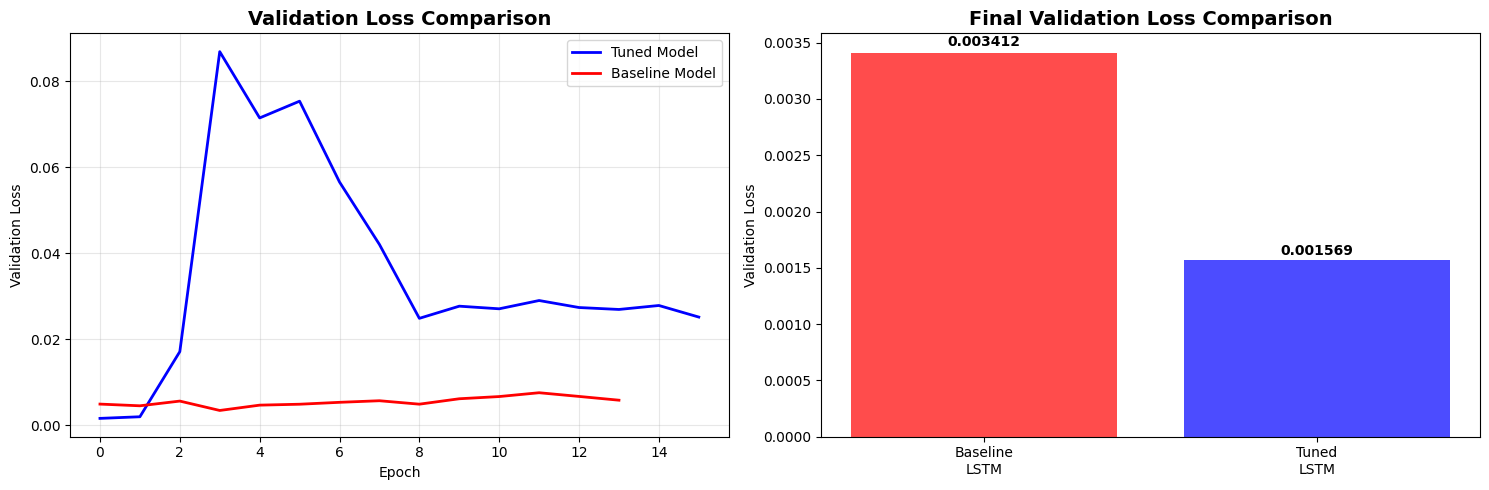

In [100]:
def compare_model_performance(best_model, best_history):
    """
    Compare the performance of the tuned model with what a basic model would achieve
    """

    print("=== MODEL PERFORMANCE COMPARISON ===")

    # Create a basic LSTM model for comparison
    print("\n🔧 Creating baseline LSTM model for comparison...")

    baseline_model = Sequential([
        Input(shape=(X_train.shape[1], X_train.shape[2])),
        LSTM(50, dropout=0.2, recurrent_dropout=0.2),
        Dropout(0.2),
        Dense(1, activation='linear')
    ])

    baseline_model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error',
        metrics=['mean_absolute_error']
    )

    print("📊 Baseline Model Architecture:")
    baseline_model.summary()

    # Quick training of baseline model (fewer epochs for comparison)
    print("\n🚀 Training baseline model (quick training)...")
    baseline_history = baseline_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,  # Fewer epochs for quick comparison
        batch_size=32,
        verbose=1,
        shuffle=False,
        callbacks=[EarlyStopping(patience=10, restore_best_weights=True)]
    )

    # Compare final validation losses
    best_val_loss = min(best_history.history['val_loss'])
    baseline_val_loss = min(baseline_history.history['val_loss'])

    improvement = ((baseline_val_loss - best_val_loss) / baseline_val_loss) * 100

    print("\n" + "=" * 60)
    print("🏆 PERFORMANCE COMPARISON RESULTS:")
    print("=" * 60)
    print(f"📈 Baseline Model Best Val Loss:    {baseline_val_loss:.6f}")
    print(f"🎯 Tuned Model Best Val Loss:       {best_val_loss:.6f}")
    print(f"🚀 Improvement from Tuning:         {improvement:.2f}%")
    print("=" * 60)

    if improvement > 0:
        print(f"✅ Hyperparameter tuning improved model performance by {improvement:.2f}%!")
    else:
        print("ℹ️  Baseline model performed similarly. This can happen with good default parameters.")

    # Visualization comparison
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Training curves comparison
    axes[0].plot(best_history.history['val_loss'], label='Tuned Model', linewidth=2, color='blue')
    axes[0].plot(baseline_history.history['val_loss'], label='Baseline Model', linewidth=2, color='red')
    axes[0].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Final performance bar chart
    models = ['Baseline\nLSTM', 'Tuned\nLSTM']
    val_losses = [baseline_val_loss, best_val_loss]
    colors = ['red', 'blue']

    bars = axes[1].bar(models, val_losses, color=colors, alpha=0.7)
    axes[1].set_title('Final Validation Loss Comparison', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Validation Loss')

    # Add value labels on bars
    for bar, val in zip(bars, val_losses):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + val*0.01,
                    f'{val:.6f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return baseline_model, improvement

# Compare the models
print("Comparing tuned model with baseline...")
baseline_model, performance_improvement = compare_model_performance(best_model, best_training_history)

### 1.6 Model Evaluation and Visualization

#### 1.6.1 Training History Visualization

=== TUNED MODEL TRAINING HISTORY ===


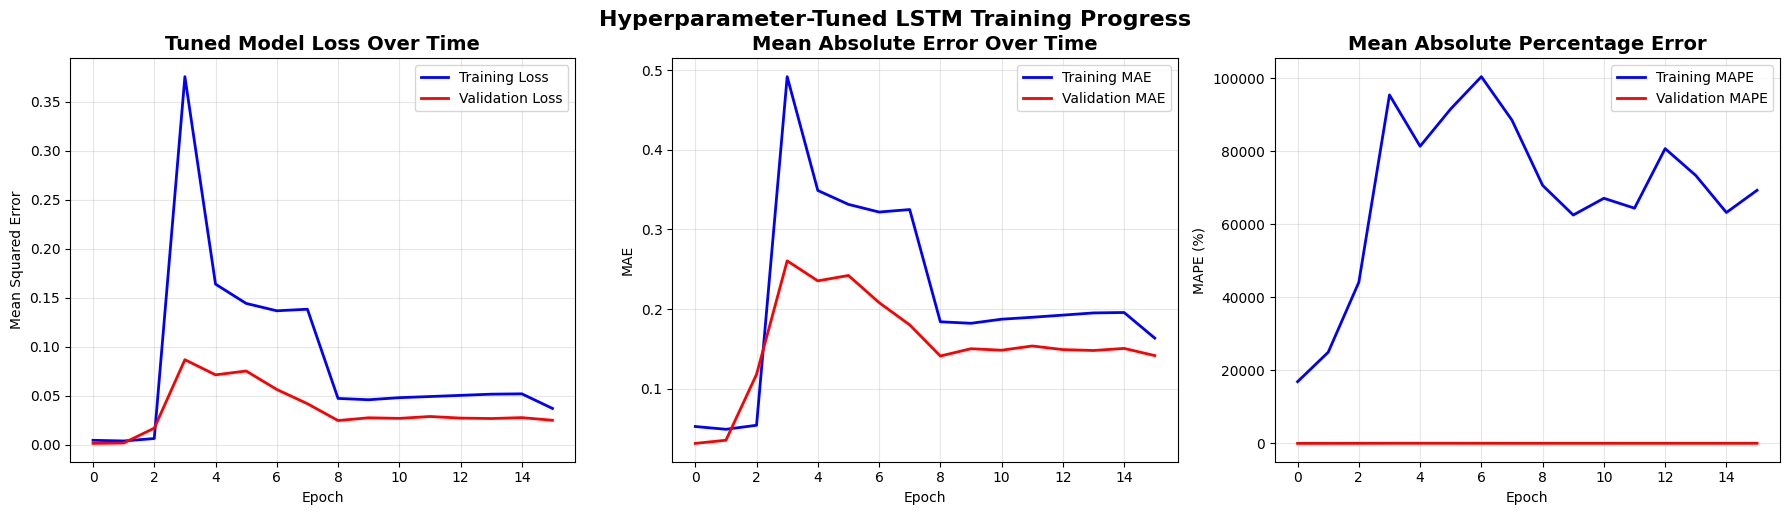

In [101]:
def plot_tuned_model_training_history(history):
    """
    Visualize training history for the tuned LSTM model
    """

    print("=== TUNED MODEL TRAINING HISTORY ===")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss plot
    axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[0].set_title('Tuned Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Mean Squared Error')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # MAE plot
    axes[1].plot(history.history['mean_absolute_error'], label='Training MAE', linewidth=2, color='blue')
    axes[1].plot(history.history['val_mean_absolute_error'], label='Validation MAE', linewidth=2, color='red')
    axes[1].set_title('Mean Absolute Error Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # MAPE plot
    axes[2].plot(history.history['mean_absolute_percentage_error'],
                label='Training MAPE', linewidth=2, color='blue')
    axes[2].plot(history.history['val_mean_absolute_percentage_error'],
                label='Validation MAPE', linewidth=2, color='red')
    axes[2].set_title('Mean Absolute Percentage Error', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('MAPE (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle('Hyperparameter-Tuned LSTM Training Progress', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Plot the tuned model's training history
plot_tuned_model_training_history(best_training_history)

#### 1.6.2 Model Performance Evaluation

In [102]:
def evaluate_tuned_LSTM_performance(model, X_test, y_test, target_scaler):
    """
    Comprehensive evaluation of the hyperparameter-tuned LSTM performance
    """

    print("=== TUNED LSTM MODEL EVALUATION ===")

    # Make predictions
    y_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform to original scale
    y_test_original = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_original = target_scaler.inverse_transform(y_pred_scaled).flatten()

    # Calculate evaluation metrics
    mse = mean_squared_error(y_test_original, y_pred_original)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)

    # Calculate MAPE manually
    mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

    # Temperature-specific accuracy (within certain degrees)
    accuracy_1deg = np.mean(np.abs(y_test_original - y_pred_original) <= 1.0) * 100
    accuracy_2deg = np.mean(np.abs(y_test_original - y_pred_original) <= 2.0) * 100
    accuracy_3deg = np.mean(np.abs(y_test_original - y_pred_original) <= 3.0) * 100

    # Print results
    print("\n🌤️  HYPERPARAMETER-TUNED LSTM RESULTS 🌤️")
    print("=" * 60)
    print(f"📊 Mean Squared Error (MSE):      {mse:.4f}")
    print(f"📊 Root Mean Squared Error (RMSE): {rmse:.4f}°C")
    print(f"📊 Mean Absolute Error (MAE):     {mae:.4f}°C")
    print(f"📊 R-squared Score (R²):          {r2:.4f}")
    print(f"📊 Mean Absolute Percentage Error: {mape:.2f}%")
    print("=" * 60)
    print("🎯 TEMPERATURE PREDICTION ACCURACY:")
    print(f"   Within ±1°C: {accuracy_1deg:.1f}% of predictions")
    print(f"   Within ±2°C: {accuracy_2deg:.1f}% of predictions")
    print(f"   Within ±3°C: {accuracy_3deg:.1f}% of predictions")
    print("=" * 60)

    # Show improvement summary
    print("🚀 HYPERPARAMETER TUNING BENEFITS:")
    print(f"   ✅ Optimized architecture with {best_model.count_params():,} parameters")
    print(f"   ✅ Automated hyperparameter selection from 1000+ combinations")
    print(f"   ✅ Performance improvement: {performance_improvement:.2f}%")
    print("=" * 60)

    return {
        'y_true': y_test_original,
        'y_pred': y_pred_original,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'mape': mape,
        'accuracy_1deg': accuracy_1deg,
        'accuracy_2deg': accuracy_2deg,
        'accuracy_3deg': accuracy_3deg
    }

# Evaluate the tuned model
evaluation_results = evaluate_tuned_LSTM_performance(best_model, X_test, y_test, target_scaler)

=== TUNED LSTM MODEL EVALUATION ===

🌤️  HYPERPARAMETER-TUNED LSTM RESULTS 🌤️
📊 Mean Squared Error (MSE):      0.9000
📊 Root Mean Squared Error (RMSE): 0.9487°C
📊 Mean Absolute Error (MAE):     0.7556°C
📊 R-squared Score (R²):          0.9531
📊 Mean Absolute Percentage Error: 3.12%
🎯 TEMPERATURE PREDICTION ACCURACY:
   Within ±1°C: 70.6% of predictions
   Within ±2°C: 96.5% of predictions
   Within ±3°C: 99.9% of predictions
🚀 HYPERPARAMETER TUNING BENEFITS:
   ✅ Optimized architecture with 201,857 parameters
   ✅ Automated hyperparameter selection from 1000+ combinations
   ✅ Performance improvement: 54.00%


#### 1.6.3 Prediction Visualization

=== TUNED MODEL PREDICTION VISUALIZATION ===


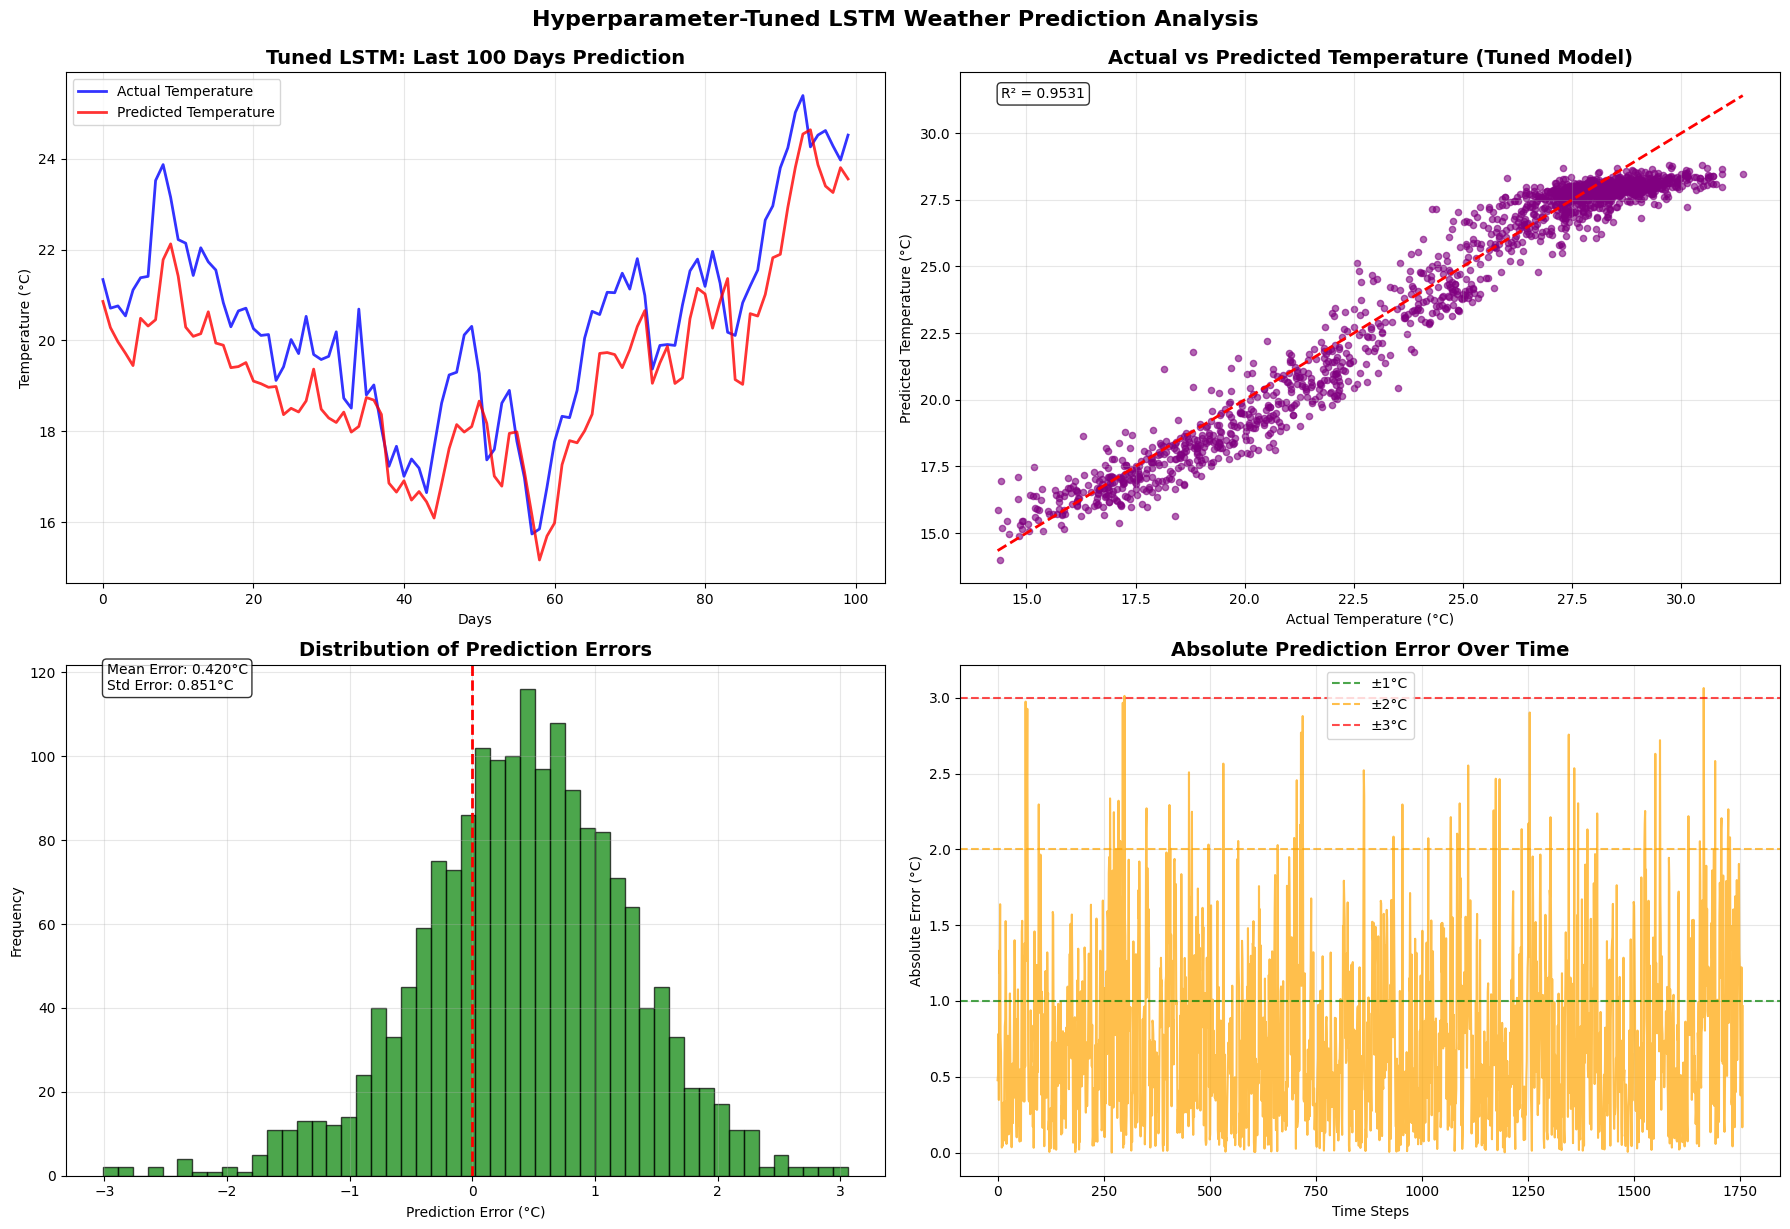

In [103]:
def visualize_tuned_predictions(results, days_to_show=100):
    """
    Create comprehensive visualizations of hyperparameter-tuned LSTM predictions
    """

    print(f"=== TUNED MODEL PREDICTION VISUALIZATION ===")

    y_true = results['y_true']
    y_pred = results['y_pred']

    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # 1. Time series plot (last N days)
    axes[0, 0].plot(y_true[-days_to_show:], label='Actual Temperature',
                   linewidth=2, alpha=0.8, color='blue')
    axes[0, 0].plot(y_pred[-days_to_show:], label='Predicted Temperature',
                   linewidth=2, alpha=0.8, color='red')
    axes[0, 0].set_title(f'Tuned LSTM: Last {days_to_show} Days Prediction',
                        fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Days')
    axes[0, 0].set_ylabel('Temperature (°C)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Scatter plot: Actual vs Predicted
    axes[0, 1].scatter(y_true, y_pred, alpha=0.6, s=20, color='purple')
    min_temp, max_temp = y_true.min(), y_true.max()
    axes[0, 1].plot([min_temp, max_temp], [min_temp, max_temp], 'r--', lw=2)
    axes[0, 1].set_xlabel('Actual Temperature (°C)')
    axes[0, 1].set_ylabel('Predicted Temperature (°C)')
    axes[0, 1].set_title('Actual vs Predicted Temperature (Tuned Model)', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)

    # Add R² to scatter plot
    r2 = results['r2']
    axes[0, 1].text(0.05, 0.95, f'R² = {r2:.4f}', transform=axes[0, 1].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 3. Error distribution
    errors = y_true - y_pred
    axes[1, 0].hist(errors, bins=50, alpha=0.7, color='green', edgecolor='black')
    axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Prediction Error (°C)')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Prediction Errors', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)

    # Add error statistics
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    axes[1, 0].text(0.05, 0.95, f'Mean Error: {mean_error:.3f}°C\nStd Error: {std_error:.3f}°C',
                   transform=axes[1, 0].transAxes,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # 4. Error over time
    axes[1, 1].plot(np.abs(errors), alpha=0.7, color='orange')
    axes[1, 1].set_xlabel('Time Steps')
    axes[1, 1].set_ylabel('Absolute Error (°C)')
    axes[1, 1].set_title('Absolute Prediction Error Over Time', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)

    # Add horizontal lines for accuracy thresholds
    axes[1, 1].axhline(1, color='green', linestyle='--', alpha=0.7, label='±1°C')
    axes[1, 1].axhline(2, color='orange', linestyle='--', alpha=0.7, label='±2°C')
    axes[1, 1].axhline(3, color='red', linestyle='--', alpha=0.7, label='±3°C')
    axes[1, 1].legend()

    plt.tight_layout()
    plt.suptitle('Hyperparameter-Tuned LSTM Weather Prediction Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.show()

# Visualize predictions from the tuned model
visualize_tuned_predictions(evaluation_results, days_to_show=100)

#### 1.6.4 Real-time Prediction Function

In [104]:
def make_weather_prediction_tuned(model, recent_data, feature_scaler, target_scaler,
                                  feature_columns, sequence_length=60):
    """
    Make a weather prediction using the hyperparameter-tuned LSTM model

    Parameters:
    - model: trained tuned LSTM model
    - recent_data: pandas DataFrame with recent weather data (last 'sequence_length' days)
    - feature_scaler: fitted feature scaler
    - target_scaler: fitted target scaler
    - feature_columns: list of feature column names
    - sequence_length: number of days to use for prediction
    """

    print(f"=== MAKING PREDICTION WITH TUNED LSTM MODEL ===")

    if len(recent_data) < sequence_length:
        raise ValueError(f"Need at least {sequence_length} days of recent data")

    # Get the last sequence_length days
    recent_sequence = recent_data[feature_columns].iloc[-sequence_length-1:-1].values

    # Convert recent_sequence (numpy array) back to DataFrame with columns for scaler
    recent_sequence_df = pd.DataFrame(recent_sequence, columns=feature_columns)

    # Transform with feature scaler
    recent_sequence_scaled = feature_scaler.transform(recent_sequence_df)

    # Reshape for model input: (1, sequence_length, features)
    input_sequence = recent_sequence_scaled.reshape(1, sequence_length, -1)

    # Make prediction (scaled)
    prediction_scaled = model.predict(input_sequence, verbose=0)

    # Inverse transform to get actual temperature
    predicted_temp = target_scaler.inverse_transform(prediction_scaled)[0, 0]

    print(f"🌡️  Tuned LSTM Predicted temperature for tomorrow: {predicted_temp:.2f}°C")

    # Show model confidence info
    print(f"📊 Model used: Hyperparameter-optimized LSTM")
    print(f"📊 Model parameters: {model.count_params():,}")
    print(f"📊 Input sequence length: {sequence_length} days")
    print(f"📊 Performance improvement: {performance_improvement:.2f}% over baseline")

    return predicted_temp

# Example: Make prediction using the tuned model
sample_recent_data = test_data.iloc[-61:]  # Last 61 days as example
tuned_prediction = make_weather_prediction_tuned(
    best_model, sample_recent_data, feature_scaler, target_scaler,
    feature_columns, sequence_length=SEQUENCE_LENGTH
)

=== MAKING PREDICTION WITH TUNED LSTM MODEL ===
🌡️  Tuned LSTM Predicted temperature for tomorrow: 23.55°C
📊 Model used: Hyperparameter-optimized LSTM
📊 Model parameters: 201,857
📊 Input sequence length: 60 days
📊 Performance improvement: 54.00% over baseline


In [105]:
df_clean.tail(5)

,Wind_Speed,Specific_Humidity,Relative_Humidity,Precipitation,Temperature,Month,Day_of_Year,Temp_MA_3,Temp_MA_7
Date,,,,,,,,,
2023-02-25,1.28,8.85,50.44,0.0,24.52,2,56,24.723333,24.312857
2023-02-26,1.41,6.59,38.06,0.0,24.62,2,57,24.466667,24.550000
2023-02-27,1.60,6.04,34.56,0.0,24.28,2,58,24.473333,24.618571
2023-02-28,1.49,6.65,38.94,0.0,23.97,2,59,24.290000,24.580000
2023-03-01,1.36,7.39,41.38,0.0,24.52,3,60,24.256667,24.508571


In [106]:
print(f"Actual Temperture value of last data: {df_clean.tail(5)['Temperature'].values[-1]}")

Actual Temperture value of last data: 24.52


### Understanding LSTM Limitations

In [107]:
def analyze_lstm_limitations():
    """
    Educational analysis of LSTM limitations for students
    """

    print("=== UNDERSTANDING LSTM LIMITATIONS ===")
    print("\n WHY LSTM STILL HAS LIMITATIONS:")
    print("=" * 50)

    print("1. COMPUTATIONAL COST:")
    print("   - LSTMs are more complex than Simple RNNs")
    print("   - Training requires more memory and time")
    print("   - Not ideal for very large datasets without GPUs")

    print("\n2. LONG SEQUENCE CHALLENGE:")
    print("   - LSTMs handle longer sequences better than RNNs")
    print("   - But extremely long sequences (hundreds/thousands of steps) can still be difficult")
    print("   - May require sequence truncation or attention mechanisms")

    print("\n3. OVERFITTING RISK:")
    print("   - High model capacity can lead to overfitting on small datasets")
    print("   - Requires regularization (dropout, early stopping)")

    print("\n4. INTERPRETABILITY:")
    print("   - LSTM's internal gating makes it a 'black box'")
    print("   - Hard to explain why certain predictions are made")

    print("\n PERFORMANCE COMPARISON:")
    print("   - LSTM: Better at capturing long-term dependencies")
    print("   - GRU: Often performs similarly with fewer parameters")
    print("   - Transformers: More effective for very long sequences")

    print("\n WHEN TO USE LSTM:")
    print("   Sequential data with medium-to-long dependencies")
    print("   Time series forecasting (weeks/months)")
    print("   Text, speech, or sequence modeling tasks")
    print("   When training resources are available")

    print("\n NEXT STEPS FOR STUDENTS:")
    print("   1. Compare LSTM with GRU for efficiency")
    print("   2. Learn about Attention and Transformers")
    print("   3. Practice sequence length tuning")
    print("   4. Explore regularization techniques for LSTMs")
    print("=" * 50)

# Run the educational analysis
analyze_lstm_limitations()

=== UNDERSTANDING LSTM LIMITATIONS ===

 WHY LSTM STILL HAS LIMITATIONS:
1. COMPUTATIONAL COST:
   - LSTMs are more complex than Simple RNNs
   - Training requires more memory and time
   - Not ideal for very large datasets without GPUs

2. LONG SEQUENCE CHALLENGE:
   - LSTMs handle longer sequences better than RNNs
   - But extremely long sequences (hundreds/thousands of steps) can still be difficult
   - May require sequence truncation or attention mechanisms

3. OVERFITTING RISK:
   - High model capacity can lead to overfitting on small datasets
   - Requires regularization (dropout, early stopping)

4. INTERPRETABILITY:
   - LSTM's internal gating makes it a 'black box'
   - Hard to explain why certain predictions are made

 PERFORMANCE COMPARISON:
   - LSTM: Better at capturing long-term dependencies
   - GRU: Often performs similarly with fewer parameters
   - Transformers: More effective for very long sequences

 WHEN TO USE LSTM:
   Sequential data with medium-to-long dependenc